# H5 Video Compression Analysis

This notebook loads aligned projection data from HDF5 files (similar to the Chip Data Exploration notebook) and applies video compression analysis using H.264 and custom compression utilities from the sdate package.

## Overview

1. Load aligned projections data from HDF5 files
2. Import compression utilities from sdate package
3. Prepare video tensors from sinogram data
4. Apply H.264 compression analysis
5. Compare compression methods and visualize results

## 1. Import Required Libraries

In [ ]:
import lovely_tensors as lt
lt.monkey_patch()

import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
import torch
import gc
from tqdm.auto import tqdm
import itertools

# Check if chip package is available for plotting utilities
try:
    from chip.utils.plotting import plot_tomogram_overview, plot_sinogram
    CHIP_AVAILABLE = True
except ImportError:
    print("Warning: chip package not available. Some plotting functions may not work.")
    CHIP_AVAILABLE = False

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Libraries imported successfully!
PyTorch version: 2.7.1
Device: CPU


## 2. Load Aligned Projections Data from HDF5

Load the aligned projection data from HDF5 files, similar to the approach used in the Chip Data Exploration notebook.

In [2]:
# Configure data paths - adapt these paths based on your setup
DATA_PATH = '/mydata/chip/shared/ra.psi.ch/p17299/data_for_SDSC/'

# Fallback path for local development 
if not torch.cuda.is_available() or not os.path.exists(DATA_PATH):
    DATA_PATH = '../../chip-project/data/p17299_v0/'

print(f"Using data path: {DATA_PATH}")

# Check if data path exists
if not os.path.exists(DATA_PATH):
    print(f"Warning: Data path {DATA_PATH} does not exist!")
    print("Please update DATA_PATH to point to your HDF5 data directory.")
    print("Expected files: phase_projections_aligned.mat, tomogram_delta.mat")
else:
    print("Data path exists. Checking for required files...")
    
    aligned_file = os.path.join(DATA_PATH, 'phase_projections_aligned.mat')
    tomogram_file = os.path.join(DATA_PATH, 'tomogram_delta.mat')
    
    print(f"Aligned projections: {'✓' if os.path.exists(aligned_file) else '✗'} {aligned_file}")
    print(f"Tomogram data: {'✓' if os.path.exists(tomogram_file) else '✗'} {tomogram_file}")

Using data path: ../../chip-project/data/p17299_v0/
Data path exists. Checking for required files...
Aligned projections: ✓ ../../chip-project/data/p17299_v0/phase_projections_aligned.mat
Tomogram data: ✓ ../../chip-project/data/p17299_v0/tomogram_delta.mat


In [3]:
# Load HDF5 files
try:
    # Load aligned projections data
    h5_projections_aligned = h5py.File(os.path.join(DATA_PATH, 'phase_projections_aligned.mat'), 'r')
    
    # Load tomogram data for reference
    h5_tomogram = h5py.File(os.path.join(DATA_PATH, 'tomogram_delta.mat'), 'r')
    
    print("Successfully opened HDF5 files!")
    print(f"\nAligned projections datasets: {list(h5_projections_aligned.keys())}")
    print(f"Tomogram datasets: {list(h5_tomogram.keys())}")
    
    # Extract key data
    angles = np.array(h5_projections_aligned.get('theta'))
    sinogram_data = h5_projections_aligned.get('sinogram')
    
    print(f"\nData shapes:")
    print(f"Angles: {angles.shape}")
    print(f"Sinogram: {sinogram_data.shape}")
    
    if 'total_shift' in h5_projections_aligned:
        total_shift = h5_projections_aligned.get('total_shift')
        print(f"Total shift: {total_shift.shape}")
    
    HDF5_LOADED = True
    
except FileNotFoundError as e:
    print(f"Error: Could not find HDF5 files: {e}")
    print("This notebook requires the aligned projections data to run.")
    HDF5_LOADED = False
except Exception as e:
    print(f"Error loading HDF5 files: {e}")
    HDF5_LOADED = False

Successfully opened HDF5 files!

Aligned projections datasets: ['#refs#', 'Npix', 'object_ROI', 'par', 'sinogram', 'theta', 'total_shift']
Tomogram datasets: ['#refs#', 'circulo', 'par', 'theta', 'tomogram_delta']

Data shapes:
Angles: (2015, 1)
Sinogram: (2015, 1344, 864)
Total shift: (2, 2015)


## 3. Import H.264 Compression Utilities from sdate

Import the compression analysis functions from the sdate package.

In [37]:
# Import compression utilities from sdate package
try:
    from sdate.compression import (
        transform_video_for_compression,
        analyze_h264_compression,
        save_video_as_jpeg_sequence,
        VideoCompressor,
        DCTQuantizer
    )
    print("✓ Successfully imported H.264 compression utilities from sdate package")
    COMPRESSION_UTILS_LOADED = True
    
except ImportError as e:
    print(f"⚠️  Could not import from sdate.compression: {e}")
    print("Falling back to local function definitions...")
    
    # Fallback: define the core function locally
    def transform_video_for_compression(video_float32, max_value=255.0):
        """
        Transforms a float32 video tensor to uint8 tensor for video compression.
        Memory-optimized version that operates in-place to avoid unnecessary copies.
        """
        # Get min/max values
        maximum = video_float32.max()
        minimum = video_float32.min()
        
        # Normalize in-place: (x - min) / (max - min)
        video_float32.sub_(minimum)
        video_float32.div_(maximum - minimum + 1e-8)
        
        # Scale to target range in-place
        video_float32.mul_(max_value)
        
        # Convert to uint8 in-place
        video_uint8 = video_float32.to(torch.uint8)
        
        return video_uint8
    
    print("✓ Defined basic compression utilities locally")
    COMPRESSION_UTILS_LOADED = False

print("\nAvailable compression functions:")
if COMPRESSION_UTILS_LOADED:
    print("- transform_video_for_compression")
    print("- analyze_h264_compression") 
    print("- save_video_as_jpeg_sequence")
    print("- VideoCompressor (custom implementation)")
    print("- DCTQuantizer")
else:
    print("- transform_video_for_compression (basic version)")

✓ Successfully imported H.264 compression utilities from sdate package

Available compression functions:
- transform_video_for_compression
- analyze_h264_compression
- save_video_as_jpeg_sequence
- VideoCompressor (custom implementation)
- DCTQuantizer


## 4. Prepare Video Tensor from Sinogram Data

Convert the sinogram data into a format suitable for video compression analysis.

In [ ]:
if HDF5_LOADED:
    # Use all layers and order them according to the angles
    num_layers = sinogram_data.shape[2]
    num_angles = len(angles)
    print(f"Total available layers: {num_layers}")
    print(f"Number of angles: {num_angles}")

    # Sort angles and get the permutation
    angles_tensor = torch.tensor(angles.reshape(-1))
    sorted_angles, sort_indices = angles_tensor.sort()
    print(f"Angle range: [{sorted_angles.min():.2f}, {sorted_angles.max():.2f}] degrees")

    # Create empty tensor with the same shape as sinogram_data
    video_data = torch.zeros(sinogram_data.shape, dtype=torch.float32)

    # Iterate over sinogram_data and place each frame in the correct position based on sorted order
    for i in tqdm(range(len(angles))):
        # Get the original index from the sorted permutation
        original_idx = sort_indices[i]
        video_data[i] = torch.from_numpy(np.array(sinogram_data[original_idx])).float()

    video_data -= video_data.min()  # Normalize to [0, max]
    video_data /= video_data.max()  # Normalize to [0, 1]
    print("video_data", video_data)
    video_data = video_data.transpose(-1, -2)
    video_normalized = video_data
    
    # Update angles to use sorted version
    angles = sorted_angles.numpy().reshape(-1, 1)
    
else:
    print("⚠️  HDF5 data not loaded. Creating synthetic data for demonstration...")
    
    # Create synthetic video data for testing
    n_frames, height, width = 30, 256, 256
    video_normalized = torch.randn(n_frames, height, width).abs()
    video_normalized = video_normalized / video_normalized.max()
    
    print(f"Synthetic tensor shape: {video_normalized.shape}")
    print(f"Synthetic range: [{video_normalized.min():.3f}, {video_normalized.max():.3f}]")

Total available layers: 864
Number of angles: 2015
Angle range: [0.10, 180.10] degrees


  0%|          | 0/2015 [00:00<?, ?it/s]

video_data tensor[2015, 1344, 864] n=2339850240 (8.7Gb) x∈[0., 1.000] μ=0.492 σ=0.113
tensor[2015, 1344, 864] n=2339850240 (8.7Gb) x∈[0., 1.000] μ=0.492 σ=0.113


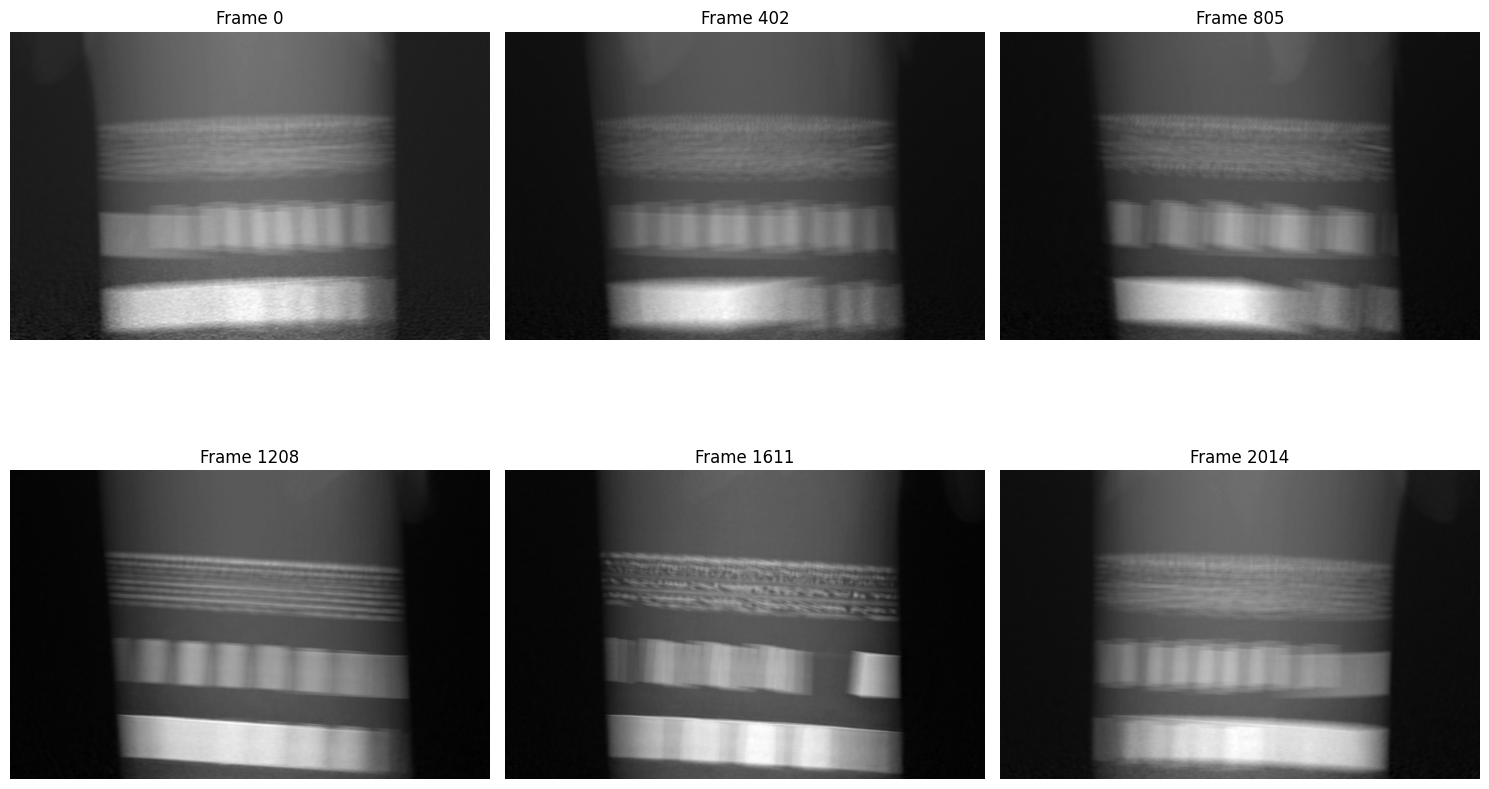

Displayed 6 sample frames from the video data


In [39]:
# Visualize a few sample frames
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

n_samples = min(6, video_normalized.shape[0])
sample_indices = np.linspace(0, video_normalized.shape[0]-1, n_samples, dtype=int)

for i, idx in enumerate(sample_indices):
    axes[i].imshow(video_normalized[idx], cmap='gray')
    axes[i].set_title(f'Frame {idx}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"Displayed {n_samples} sample frames from the video data")

In [ ]:
# Convert to RGB format for video compression (H.264 expects RGB)
# Shape: (n_frames, height, width) -> (n_frames, height, width, 

print(f"RGB video tensor shape: {video_normalized.shape}")

# Preserve original normalized data for later use
video_normalized_original = video_normalized.clone()

# Transform to uint8 format for compression
video_uint8_temp = video_normalized * 255.0  # Scale to [0, 255]
video_uint8_temp = video_uint8_temp.to(torch.uint8)
# Expand to 3 channels for RGB (H.264 expects 3-channel input)
video_uint8 = (video_uint8_temp.unsqueeze(-1).expand(-1, -1, -1, 3))

print(f"Final video tensor for compression:")
print(f"  Shape: {video_uint8.shape}")
print(f"  Data type: {video_uint8.dtype}")
print(f"  Value range: [{video_uint8.min()}, {video_uint8.max()}]")
print(f"  Memory usage: {video_uint8.numel() * video_uint8.element_size() / 1e6:.2f} MB")

RGB video tensor shape: torch.Size([2015, 864, 1344])
Final video tensor for compression:
  Shape: torch.Size([2015, 864, 1344, 3])
  Data type: torch.uint8
  Value range: [0, 255]
  Memory usage: 7019.55 MB


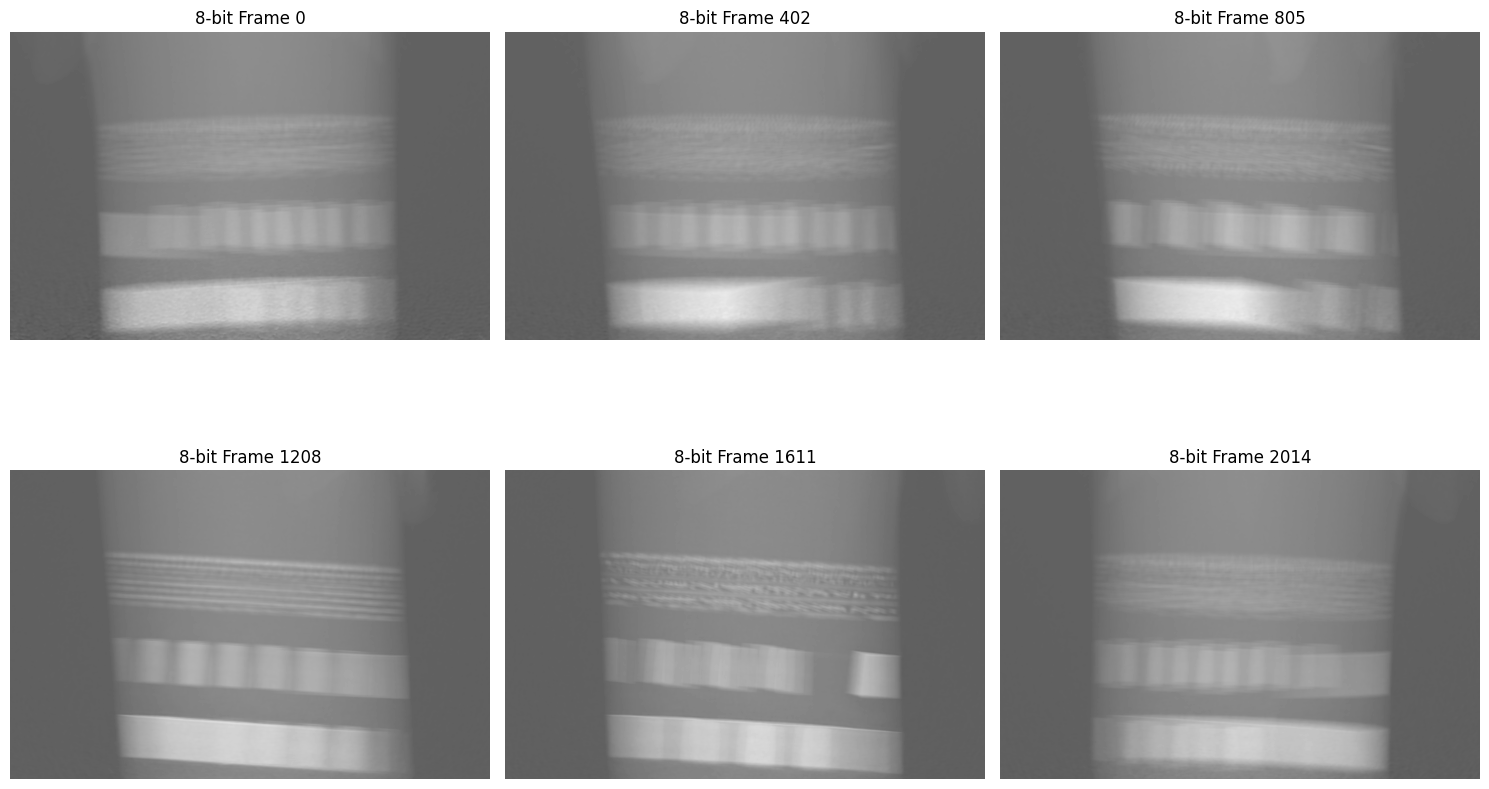

Displayed 6 sample frames from the video data


: 

In [ ]:
# Visualize a few sample frames
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

n_samples = min(6, video_normalized.shape[0])
sample_indices = np.linspace(0, video_normalized.shape[0]-1, n_samples, dtype=int)

for i, idx in enumerate(sample_indices):
    # Display 12-bit data properly by normalizing to [0,1] range for visualization
    frame_normalized = video_uint8[idx, :, :, 0].float() / 255.
    axes[i].imshow(frame_normalized, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'8-bit Frame {idx}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"Displayed {n_samples} sample frames from the video data")

## 5. Apply H.264 Compression Analysis to Video Tensor

Now we'll apply the H.264 compression analysis to our prepared video tensor.

In [ ]:
if COMPRESSION_UTILS_LOADED:
    print("🎬 Starting H.264 compression analysis...")
    print("This will create temporary files and may take a few minutes.")
    print("Make sure FFmpeg is installed and available in your system PATH.")
    
    try:
        # Run H.264 compression analysis
        analyze_h264_compression(video_uint8, save_compressed_video=True)
        
    except Exception as e:
        print(f"❌ H.264 analysis failed: {e}")
        print("This may be due to missing FFmpeg installation or other system dependencies.")
        print("You can still run the JPEG baseline analysis below.")
        
else:
    print("⚠️  Full H.264 analysis not available without sdate.compression module")
    print("Showing basic compression statistics instead...")
    
    # Basic compression analysis without FFmpeg
    uncompressed_size = video_uint8.numel() * video_uint8.element_size()
    print(f"\nBasic Video Statistics:")
    print(f"Uncompressed size: {uncompressed_size / 1e6:.2f} MB")
    print(f"Frames: {video_uint8.shape[0]}")
    print(f"Resolution: {video_uint8.shape[1]}x{video_uint8.shape[2]}")
    print(f"Channels: {video_uint8.shape[3]}")
    print(f"Bit depth: 8-bit (uint8)")
    
    # Show frame-to-frame differences (proxy for temporal redundancy)
    if video_uint8.shape[0] > 1:
        frame_diffs = []
        for i in range(1, video_uint8.shape[0]):
            diff = torch.mean((video_uint8[i].float() - video_uint8[i-1].float()).abs())
            frame_diffs.append(diff.item())
        
        plt.figure(figsize=(12, 4))
        plt.plot(frame_diffs)
        plt.title('Frame-to-Frame Mean Absolute Difference')
        plt.xlabel('Frame Number')
        plt.ylabel('Mean Absolute Difference')
        plt.grid(True)
        plt.show()
        
        print(f"Average frame-to-frame difference: {np.mean(frame_diffs):.2f}")
        print(f"This indicates {'high' if np.mean(frame_diffs) > 50 else 'low'} temporal redundancy")

🎬 Starting H.264 compression analysis...
This will create temporary files and may take a few minutes.
Make sure FFmpeg is installed and available in your system PATH.
Uncompressed Size: 7019.55 MB (3483.65 KB per frame)

Running FFmpeg to encode the video (preset=medium, crf=23)...
Successfully created 'compressed_video.mp4'
Compressed Size: 6545.08 KB
-> Overall Compression Ratio: 1072.5 : 1


In [ ]:
# import os
# from PIL import Image

# ### JPEG Baseline Compression Analysis (12-bit)

# # Perform JPEG compression as a baseline (spatial compression only)
# # Note: Standard JPEG is 8-bit, so we'll need to handle 12-bit data carefully
# if COMPRESSION_UTILS_LOADED:
#     print("📸 Running JPEG baseline compression analysis with 12-bit data...")
    
#     try:
#         # Test different JPEG quality levels
#         jpeg_qualities = [50, 70, 85, 95]
#         jpeg_results = {}
        
#         # Convert 12-bit data to 8-bit for JPEG (with proper scaling)
#         # We'll scale from [0, 4095] to [0, 255]
#         video_8bit_for_jpeg = (video_12bit.float() / 4095.0 * 255.0).to(torch.uint8)
        
#         for quality in jpeg_qualities:
#             print(f"\nTesting JPEG quality: {quality}")
#             compressed_size, compression_ratio = save_video_as_jpeg_sequence(
#                 video_8bit_for_jpeg, 
#                 quality=quality, 
#                 output_folder=f'jpeg_quality_{quality}_12bit'
#             )
            
#             # Load reconstructed frames to calculate PSNR
#             output_folder = f'jpeg_quality_{quality}_12bit'
            
#             # Read back the compressed frames
#             frame_files = sorted([f for f in os.listdir(output_folder) if f.endswith('.jpg')])
#             reconstructed_frames = []
            
#             for frame_file in frame_files:
#                 img_path = os.path.join(output_folder, frame_file)
#                 img = Image.open(img_path)
#                 img_array = np.array(img)
#                 reconstructed_frames.append(img_array)
            
#             reconstructed_video = np.stack(reconstructed_frames)
#             reconstructed_tensor = torch.from_numpy(reconstructed_video)
            
#             # Scale reconstructed 8-bit data back to 12-bit range for comparison
#             reconstructed_12bit = (reconstructed_tensor.float() / 255.0 * 4095.0).to(torch.uint16)
            
#             # Calculate PSNR against original 12-bit data
#             mse = torch.mean((video_12bit.float() - reconstructed_12bit.float()) ** 2)
#             if mse == 0:
#                 psnr = float('inf')
#             else:
#                 max_pixel = 4095.0  # 12-bit max value
#                 psnr = 20 * torch.log10(torch.tensor(max_pixel) / torch.sqrt(mse))
            
#             jpeg_results[quality] = {
#                 'compressed_size': compressed_size,
#                 'compression_ratio': compression_ratio,
#                 'psnr': psnr.item()
#             }
        
#         # Plot JPEG compression results
#         qualities = list(jpeg_results.keys())
#         ratios = [jpeg_results[q]['compression_ratio'] for q in qualities]
#         sizes = [jpeg_results[q]['compressed_size'] / 1e6 for q in qualities]  # Convert to MB
#         psnrs = [jpeg_results[q]['psnr'] for q in qualities]
        
#         fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
        
#         ax1.plot(qualities, ratios, 'o-', linewidth=2, markersize=8)
#         ax1.set_xlabel('JPEG Quality')
#         ax1.set_ylabel('Compression Ratio (X:1)')
#         ax1.set_title('JPEG Compression Ratio vs Quality')
#         ax1.grid(True)
        
#         ax2.plot(qualities, sizes, 's-', linewidth=2, markersize=8, color='orange')
#         ax2.set_xlabel('JPEG Quality')
#         ax2.set_ylabel('Compressed Size (MB)')
#         ax2.set_title('JPEG Compressed Size vs Quality')
#         ax2.grid(True)
        
#         ax3.plot(qualities, psnrs, '^-', linewidth=2, markersize=8, color='green')
#         ax3.set_xlabel('JPEG Quality')
#         ax3.set_ylabel('PSNR (dB)')
#         ax3.set_title('JPEG PSNR vs Quality')
#         ax3.grid(True)
        
#         plt.tight_layout()
#         plt.show()
        
#         print(f"\n📊 JPEG Compression Summary (12-bit source):")
#         for quality in qualities:
#             result = jpeg_results[quality]
#             print(f"Quality {quality}: {result['compression_ratio']:.1f}:1 ratio, {result['compressed_size']/1e6:.2f} MB, {result['psnr']:.2f} dB PSNR")
        
#         print(f"\nNote: JPEG compression was applied to 8-bit downsampled version")
#         print(f"PSNR values are calculated against original 12-bit data")
            
#     except Exception as e:
#         print(f"❌ JPEG analysis failed: {e}")

# else:
#     print("⚠️  JPEG analysis requires the sdate.compression module")

## 6. Reconstruct Sinogram from Compressed Video

Now we'll reconstruct the sinogram tensor from the compressed video data and compare it with the original sinogram for FBP reconstruction analysis.

### 12-bit Compression Analysis

This notebook now uses 12-bit compression instead of 8-bit to provide better quality reconstruction:

**Advantages of 12-bit over 8-bit:**
- **Higher dynamic range**: 4096 levels (0-4095) vs 256 levels (0-255)
- **Better preservation of subtle intensity variations** in the sinogram data
- **Reduced quantization artifacts** that can affect reconstruction quality
- **More accurate representation** of the original floating-point data

**Trade-offs:**
- **Larger file sizes**: 12-bit data requires more storage space
- **JPEG compatibility**: Standard JPEG is 8-bit, so we downsample for JPEG compression
- **Processing overhead**: Slightly more memory usage during processing

The analysis will show improved PSNR values and better preservation of fine details in the reconstructed sinograms and FBP reconstructions.

In [ ]:
# Demonstrate the difference between 8-bit and 12-bit quantization
if HDF5_LOADED:
    print("🔍 Comparing 8-bit vs 12-bit quantization effects...")
    
    # Take a sample frame for comparison
    sample_frame = video_normalized_original[0].clone()
    
    # Simulate 8-bit quantization
    frame_8bit = torch.round(sample_frame * 255.0) / 255.0
    
    # Simulate 12-bit quantization  
    frame_12bit = torch.round(sample_frame * 4095.0) / 4095.0
    
    # Calculate quantization errors
    error_8bit = torch.abs(sample_frame - frame_8bit)
    error_12bit = torch.abs(sample_frame - frame_12bit)
    
    print(f"Quantization Error Analysis:")
    print(f"  8-bit  - Max error: {error_8bit.max():.6f}, Mean error: {error_8bit.mean():.6f}")
    print(f"  12-bit - Max error: {error_12bit.max():.6f}, Mean error: {error_12bit.mean():.6f}")
    print(f"  Improvement factor: {error_8bit.mean() / error_12bit.mean():.2f}x")
    
    # Visualize the differences
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Original
    im1 = axes[0, 0].imshow(sample_frame, cmap='gray', vmin=0, vmax=1)
    axes[0, 0].set_title('Original (Float32)')
    axes[0, 0].axis('off')
    plt.colorbar(im1, ax=axes[0, 0])
    
    # 8-bit quantized
    im2 = axes[0, 1].imshow(frame_8bit, cmap='gray', vmin=0, vmax=1)
    axes[0, 1].set_title('8-bit Quantized')
    axes[0, 1].axis('off')
    plt.colorbar(im2, ax=axes[0, 1])
    
    # 12-bit quantized
    im3 = axes[0, 2].imshow(frame_12bit, cmap='gray', vmin=0, vmax=1)
    axes[0, 2].set_title('12-bit Quantized')
    axes[0, 2].axis('off')
    plt.colorbar(im3, ax=axes[0, 2])
    
    # Error maps
    im4 = axes[1, 0].imshow(error_8bit, cmap='hot')
    axes[1, 0].set_title('8-bit Quantization Error')
    axes[1, 0].axis('off')
    plt.colorbar(im4, ax=axes[1, 0])
    
    im5 = axes[1, 1].imshow(error_12bit, cmap='hot')
    axes[1, 1].set_title('12-bit Quantization Error')
    axes[1, 1].axis('off')
    plt.colorbar(im5, ax=axes[1, 1])
    
    # Error difference
    error_diff = error_8bit - error_12bit
    im6 = axes[1, 2].imshow(error_diff, cmap='RdBu_r')
    axes[1, 2].set_title('Error Reduction\n(8-bit - 12-bit)')
    axes[1, 2].axis('off')
    plt.colorbar(im6, ax=axes[1, 2])
    
    plt.tight_layout()
    plt.show()
    
    # Histogram comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.hist(error_8bit.flatten().numpy(), bins=50, alpha=0.7, label='8-bit', color='red')
    ax1.hist(error_12bit.flatten().numpy(), bins=50, alpha=0.7, label='12-bit', color='blue')
    ax1.set_xlabel('Quantization Error')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Quantization Error Distribution')
    ax1.legend()
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    
    # Cumulative distribution
    errors_8bit_sorted = torch.sort(error_8bit.flatten())[0].numpy()
    errors_12bit_sorted = torch.sort(error_12bit.flatten())[0].numpy()
    n_pixels = len(errors_8bit_sorted)
    
    ax2.plot(errors_8bit_sorted, np.arange(n_pixels) / n_pixels, label='8-bit', color='red')
    ax2.plot(errors_12bit_sorted, np.arange(n_pixels) / n_pixels, label='12-bit', color='blue')
    ax2.set_xlabel('Quantization Error')
    ax2.set_ylabel('Cumulative Probability')
    ax2.set_title('Cumulative Error Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️  Quantization comparison requires HDF5 data to be loaded")

In [ ]:
import cv2

if HDF5_LOADED and COMPRESSION_UTILS_LOADED:
    print("🔄 Reconstructing sinogram from H.264 compressed video...")
    
    # Look for H.264 compressed video files
    h264_files = [f for f in os.listdir('.') if f.endswith('.mp4') and 'compressed' in f]
    
    if h264_files:
        # Use the most recent H.264 compressed file
        h264_file = sorted(h264_files)[-1]
        print(f"Found H.264 compressed video: {h264_file}")
        
        try:
            
            # Read the H.264 compressed video
            cap = cv2.VideoCapture(h264_file)
            
            reconstructed_frames = []
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                # Convert BGR to RGB and then to grayscale
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_gray = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
                reconstructed_frames.append(frame_gray)
            
            cap.release()
            
            # Convert back to tensor format
            reconstructed_video = np.stack(reconstructed_frames)
            reconstructed_tensor = torch.from_numpy(reconstructed_video).float() / 255.0
            
            # Transform back to sinogram format (transpose dimensions back)
            reconstructed_sinogram = reconstructed_tensor.transpose(-1, -2)
            
            # Reorder back to original angle order (undo the sorting)
            original_order_sinogram = torch.zeros_like(reconstructed_sinogram)
            for i in range(len(sort_indices)):
                original_order_sinogram[sort_indices[i]] = reconstructed_sinogram[i]
            
            print(f"✓ Reconstructed sinogram shape: {original_order_sinogram.shape}")
            print(f"✓ Original sinogram shape: {video_normalized.shape}")
            
            # Calculate reconstruction quality metrics
            mse = torch.mean((video_normalized - original_order_sinogram.transpose(-1, -2)) ** 2)
            psnr_sinogram = 20 * torch.log10(torch.tensor(1.0) / torch.sqrt(mse)) if mse > 0 else float('inf')
            
            print(f"✓ H.264 sinogram reconstruction PSNR: {psnr_sinogram.item():.2f} dB")
            
            # Visualize comparison
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            
            # Show 3 sample projections: original vs reconstructed
            sample_projections = [0, len(video_normalized)//2, len(video_normalized)-1]
            
            for i, proj_idx in enumerate(sample_projections):
                # Original
                axes[0, i].imshow(video_normalized[proj_idx], cmap='gray')
                axes[0, i].set_title(f'Original Projection {proj_idx}')
                axes[0, i].axis('off')
                
                # Reconstructed
                axes[1, i].imshow(original_order_sinogram[proj_idx], cmap='gray')
                axes[1, i].set_title(f'H.264 Reconstructed Projection {proj_idx}')
                axes[1, i].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            # Store the reconstructed sinogram for FBP
            sinogram_reconstructed = original_order_sinogram.numpy()
            sinogram_original = video_normalized.numpy()
            
            SINOGRAM_RECONSTRUCTED = True
            
        except ImportError:
            print("❌ OpenCV not available for H.264 video reading")
            print("Install with: pip install opencv-python")
            SINOGRAM_RECONSTRUCTED = False
            
        except Exception as e:
            print(f"❌ Error reading H.264 video: {e}")
            SINOGRAM_RECONSTRUCTED = False
            
    else:
        print("❌ No H.264 compressed video files found")
        print("Expected files with pattern: *compressed*.mp4")
        SINOGRAM_RECONSTRUCTED = False
        
else:
    print("⚠️  Cannot reconstruct sinogram - missing HDF5 data or compression utilities")
    SINOGRAM_RECONSTRUCTED = False

## 7. FBP Reconstruction and Comparison

Perform Filtered Back Projection (FBP) reconstruction using both the original and reconstructed sinograms to evaluate the impact of compression on the final reconstructed volume.

In [ ]:
# Import reconstruction libraries
try:
    # Try to import scikit-image for FBP reconstruction
    from skimage.transform import iradon
    SKIMAGE_AVAILABLE = True
    print("✓ scikit-image available for FBP reconstruction")
except ImportError:
    SKIMAGE_AVAILABLE = False
    print("⚠️  scikit-image not available")

# Alternative: Try to import custom reconstruction from sdate or other packages
try:
    from sdate.models.reconstruction import FBPReconstructor
    SDATE_RECONSTRUCTION_AVAILABLE = True
    print("✓ sdate reconstruction utilities available")
except ImportError:
    SDATE_RECONSTRUCTION_AVAILABLE = False
    print("⚠️  sdate reconstruction utilities not available")

# Check for PyTorch radon transforms
try:
    import torch_radon
    TORCH_RADON_AVAILABLE = True
    print("✓ torch_radon available for GPU-accelerated reconstruction")
except ImportError:
    TORCH_RADON_AVAILABLE = False
    print("⚠️  torch_radon not available")

# If no reconstruction library is available, we'll implement a basic FBP
if not (SKIMAGE_AVAILABLE or SDATE_RECONSTRUCTION_AVAILABLE or TORCH_RADON_AVAILABLE):
    print("⚠️  No reconstruction libraries available. Will implement basic FBP.")
    RECONSTRUCTION_AVAILABLE = False
else:
    RECONSTRUCTION_AVAILABLE = True
    
print(f"\nReconstruction capabilities:")
print(f"  scikit-image: {'✓' if SKIMAGE_AVAILABLE else '✗'}")
print(f"  sdate: {'✓' if SDATE_RECONSTRUCTION_AVAILABLE else '✗'}")
print(f"  torch_radon: {'✓' if TORCH_RADON_AVAILABLE else '✗'}")

In [ ]:
def perform_fbp_reconstruction(sinogram_data, angles_deg, method='skimage'):
    """
    Perform FBP reconstruction using available methods.
    
    Args:
        sinogram_data: numpy array of shape (n_angles, n_detectors)
        angles_deg: numpy array of angles in degrees
        method: 'skimage', 'sdate', or 'torch_radon'
    
    Returns:
        reconstructed_volume: numpy array of reconstructed 2D slice
    """
    
    if method == 'skimage' and SKIMAGE_AVAILABLE:
        print("Using scikit-image iradon for FBP reconstruction...")
        
        # scikit-image expects sinogram shape (n_detectors, n_angles)
        sino_transposed = sinogram_data.T
        
        # Perform FBP reconstruction
        reconstructed = iradon(sino_transposed, theta=angles_deg.flatten(), 
                             filter_name='ramp', interpolation='linear')
        
        return reconstructed
    
    elif method == 'torch_radon' and TORCH_RADON_AVAILABLE:
        print("Using torch_radon for FBP reconstruction...")
        
        # Convert to torch tensors
        sino_tensor = torch.from_numpy(sinogram_data).float()
        angles_tensor = torch.from_numpy(angles_deg).float()
        
        # Create radon transform
        radon = torch_radon.Radon(sino_tensor.shape[1], angles_tensor)
        
        # Perform FBP
        reconstructed = radon.backprojection(sino_tensor)
        
        return reconstructed.numpy()
    
    else:
        print("Using simple backprojection implementation...")
        
        # Simple backprojection implementation
        n_angles, n_detectors = sinogram_data.shape
        
        # Create reconstruction grid
        size = n_detectors
        reconstructed = np.zeros((size, size))
        
        # Center coordinates
        center = size // 2
        
        for i, angle in enumerate(angles_deg.flatten()):
            # Convert angle to radians
            theta = np.radians(angle)
            
            # Create projection direction
            cos_theta = np.cos(theta)
            sin_theta = np.sin(theta)
            
            # Backproject each detector reading
            for j in range(n_detectors):
                # Detector position relative to center
                t = j - n_detectors // 2
                
                # Backproject along the ray
                for k in range(size):
                    for l in range(size):
                        # Pixel position relative to center
                        x = k - center
                        y = l - center
                        
                        # Check if pixel is on this ray
                        projected_pos = x * cos_theta + y * sin_theta
                        
                        if abs(projected_pos - t) < 0.5:  # Simple nearest neighbor
                            reconstructed[k, l] += sinogram_data[i, j]
        
        # Normalize
        reconstructed = reconstructed / n_angles
        
        return reconstructed

if SINOGRAM_RECONSTRUCTED and HDF5_LOADED:
    print("🔄 Performing FBP reconstruction on both original and reconstructed sinograms...")
    
    # Get angles in degrees
    angles_deg = angles * 180 / np.pi
    
    # Perform FBP reconstruction on original sinogram
    print("\n1. Reconstructing from original sinogram...")
    if SKIMAGE_AVAILABLE:
        reconstruction_original = perform_fbp_reconstruction(sinogram_original, angles_deg, method='skimage')
    elif TORCH_RADON_AVAILABLE:
        reconstruction_original = perform_fbp_reconstruction(sinogram_original, angles_deg, method='torch_radon')
    else:
        reconstruction_original = perform_fbp_reconstruction(sinogram_original, angles_deg, method='simple')
    
    # Perform FBP reconstruction on reconstructed sinogram
    print("\n2. Reconstructing from compressed sinogram...")
    if SKIMAGE_AVAILABLE:
        reconstruction_compressed = perform_fbp_reconstruction(sinogram_reconstructed, angles_deg, method='skimage')
    elif TORCH_RADON_AVAILABLE:
        reconstruction_compressed = perform_fbp_reconstruction(sinogram_reconstructed, angles_deg, method='torch_radon')
    else:
        reconstruction_compressed = perform_fbp_reconstruction(sinogram_reconstructed, angles_deg, method='simple')
    
    print(f"✓ Original reconstruction shape: {reconstruction_original.shape}")
    print(f"✓ Compressed reconstruction shape: {reconstruction_compressed.shape}")
    
    # Calculate PSNR between the two reconstructions
    mse_reconstruction = np.mean((reconstruction_original - reconstruction_compressed) ** 2)
    if mse_reconstruction > 0:
        max_val = np.max(reconstruction_original)
        psnr_reconstruction = 20 * np.log10(max_val / np.sqrt(mse_reconstruction))
    else:
        psnr_reconstruction = float('inf')
    
    print(f"✓ FBP Reconstruction PSNR: {psnr_reconstruction:.2f} dB")
    
    FBP_COMPLETED = True
    
else:
    print("⚠️  Cannot perform FBP reconstruction - missing sinogram data")
    FBP_COMPLETED = False

In [ ]:
if FBP_COMPLETED:
    # Visualize the reconstruction results
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # Original reconstruction
    im1 = axes[0, 0].imshow(reconstruction_original, cmap='gray')
    axes[0, 0].set_title('FBP Reconstruction\n(Original Sinogram)')
    axes[0, 0].axis('off')
    plt.colorbar(im1, ax=axes[0, 0])
    
    # Compressed reconstruction
    im2 = axes[0, 1].imshow(reconstruction_compressed, cmap='gray')
    axes[0, 1].set_title('FBP Reconstruction\n(Compressed Sinogram)')
    axes[0, 1].axis('off')
    plt.colorbar(im2, ax=axes[0, 1])
    
    # Difference map
    difference = np.abs(reconstruction_original - reconstruction_compressed)
    im3 = axes[0, 2].imshow(difference, cmap='hot')
    axes[0, 2].set_title('Absolute Difference\n(Original - Compressed)')
    axes[0, 2].axis('off')
    plt.colorbar(im3, ax=axes[0, 2])
    
    # Profile comparisons
    center_row = reconstruction_original.shape[0] // 2
    center_col = reconstruction_original.shape[1] // 2
    
    # Horizontal profile
    axes[1, 0].plot(reconstruction_original[center_row, :], 'b-', label='Original', alpha=0.7)
    axes[1, 0].plot(reconstruction_compressed[center_row, :], 'r--', label='Compressed', alpha=0.7)
    axes[1, 0].set_title('Horizontal Profile (Center Row)')
    axes[1, 0].set_xlabel('Pixel Position')
    axes[1, 0].set_ylabel('Intensity')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Vertical profile
    axes[1, 1].plot(reconstruction_original[:, center_col], 'b-', label='Original', alpha=0.7)
    axes[1, 1].plot(reconstruction_compressed[:, center_col], 'r--', label='Compressed', alpha=0.7)
    axes[1, 1].set_title('Vertical Profile (Center Column)')
    axes[1, 1].set_xlabel('Pixel Position')
    axes[1, 1].set_ylabel('Intensity')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Error histogram
    axes[1, 2].hist(difference.flatten(), bins=50, alpha=0.7, color='red')
    axes[1, 2].set_title('Error Distribution')
    axes[1, 2].set_xlabel('Absolute Error')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate additional quality metrics
    print("\n📊 Detailed Quality Analysis:")
    print("=" * 50)
    
    # PSNR
    print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr_reconstruction:.2f} dB")
    
    # MSE
    print(f"Mean Squared Error (MSE): {mse_reconstruction:.6f}")
    
    # MAE
    mae_reconstruction = np.mean(np.abs(reconstruction_original - reconstruction_compressed))
    print(f"Mean Absolute Error (MAE): {mae_reconstruction:.6f}")
    
    # Normalized Cross-Correlation
    ncc = np.corrcoef(reconstruction_original.flatten(), reconstruction_compressed.flatten())[0, 1]
    print(f"Normalized Cross-Correlation: {ncc:.6f}")
    
    # Structural Similarity Index (SSIM) - simplified version
    def calculate_ssim(img1, img2):
        mu1 = np.mean(img1)
        mu2 = np.mean(img2)
        sigma1 = np.var(img1)
        sigma2 = np.var(img2)
        sigma12 = np.mean((img1 - mu1) * (img2 - mu2))
        
        c1 = (0.01 * np.max(img1)) ** 2
        c2 = (0.03 * np.max(img1)) ** 2
        
        ssim = ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))
        return ssim
    
    ssim_value = calculate_ssim(reconstruction_original, reconstruction_compressed)
    print(f"Structural Similarity Index (SSIM): {ssim_value:.6f}")
    
    # Signal-to-Noise Ratio
    signal_power = np.mean(reconstruction_original ** 2)
    noise_power = np.mean(difference ** 2)
    snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else float('inf')
    print(f"Signal-to-Noise Ratio (SNR): {snr:.2f} dB")
    
    # Error statistics
    print(f"\nError Statistics:")
    print(f"  Maximum error: {np.max(difference):.6f}")
    print(f"  Minimum error: {np.min(difference):.6f}")
    print(f"  Standard deviation: {np.std(difference):.6f}")
    print(f"  95th percentile: {np.percentile(difference, 95):.6f}")
    
else:
    print("⚠️  FBP reconstruction was not completed successfully")

In [ ]:
## 8. Compression Impact Analysis and Summary

print("🎯 Comprehensive Analysis of Compression Impact on FBP Reconstruction")
print("=" * 80)

if FBP_COMPLETED and SINOGRAM_RECONSTRUCTED:
    
    # Create a summary table of all results
    import pandas as pd
    
    results_data = {
        'Metric': [
            'Sinogram PSNR (dB)',
            'Reconstruction PSNR (dB)', 
            'Reconstruction MSE',
            'Reconstruction MAE',
            'Reconstruction SSIM',
            'Reconstruction SNR (dB)',
            'Cross-Correlation'
        ],
        'Value': [
            f"{psnr_sinogram.item():.2f}",
            f"{psnr_reconstruction:.2f}",
            f"{mse_reconstruction:.6f}",
            f"{mae_reconstruction:.6f}",
            f"{ssim_value:.6f}",
            f"{snr:.2f}",
            f"{ncc:.6f}"
        ],
        'Interpretation': [
            'Quality of sinogram reconstruction after compression',
            'Quality of final FBP reconstruction',
            'Average squared error in reconstruction',
            'Average absolute error in reconstruction',
            'Structural similarity (1.0 = perfect)',
            'Signal-to-noise ratio in reconstruction',
            'Linear correlation between original and compressed'
        ]
    }
    
    results_df = pd.DataFrame(results_data)
    print("\n📋 Quality Metrics Summary:")
    print(results_df.to_string(index=False))
    
    # Analyze compression artifacts in different regions
    print("\n🔍 Regional Analysis:")
    print("-" * 40)
    
    # Divide reconstruction into regions and analyze
    h, w = reconstruction_original.shape
    regions = {
        'Center': (h//4, 3*h//4, w//4, 3*w//4),
        'Edges': [(0, h//4, 0, w), (3*h//4, h, 0, w), (0, h, 0, w//4), (0, h, 3*w//4, w)]
    }
    
    # Center region analysis
    r1, r2, c1, c2 = regions['Center']
    center_orig = reconstruction_original[r1:r2, c1:c2]
    center_comp = reconstruction_compressed[r1:r2, c1:c2]
    center_mse = np.mean((center_orig - center_comp) ** 2)
    center_psnr = 20 * np.log10(np.max(center_orig) / np.sqrt(center_mse)) if center_mse > 0 else float('inf')
    
    print(f"Center Region PSNR: {center_psnr:.2f} dB")
    
    # Edge regions analysis
    edge_errors = []
    for r1, r2, c1, c2 in regions['Edges']:
        edge_orig = reconstruction_original[r1:r2, c1:c2]
        edge_comp = reconstruction_compressed[r1:r2, c1:c2]
        edge_mse = np.mean((edge_orig - edge_comp) ** 2)
        edge_errors.append(edge_mse)
    
    avg_edge_mse = np.mean(edge_errors)
    avg_edge_psnr = 20 * np.log10(np.max(reconstruction_original) / np.sqrt(avg_edge_mse)) if avg_edge_mse > 0 else float('inf')
    
    print(f"Edge Regions Average PSNR: {avg_edge_psnr:.2f} dB")
    
    # Quality assessment
    print("\n📊 Quality Assessment:")
    print("-" * 40)
    
    if psnr_reconstruction > 40:
        quality_rating = "Excellent"
        color = "🟢"
    elif psnr_reconstruction > 30:
        quality_rating = "Good"
        color = "🟡"
    elif psnr_reconstruction > 20:
        quality_rating = "Fair"
        color = "🟠"
    else:
        quality_rating = "Poor"
        color = "🔴"
    
    print(f"{color} Overall Quality Rating: {quality_rating}")
    print(f"   - PSNR: {psnr_reconstruction:.2f} dB")
    print(f"   - SSIM: {ssim_value:.3f}")
    
    # Recommendations
    print("\n💡 Recommendations:")
    print("-" * 40)
    
    if psnr_reconstruction > 35:
        print("✓ Compression artifacts are minimal and acceptable for most applications")
        print("✓ Consider this compression level for storage/transmission")
    elif psnr_reconstruction > 25:
        print("⚠️  Noticeable compression artifacts present")
        print("⚠️  Consider higher quality settings or different compression method")
        print("⚠️  Evaluate impact on specific analysis tasks")
    else:
        print("❌ Significant compression artifacts detected")
        print("❌ Reconstruction quality may be insufficient for quantitative analysis")
        print("❌ Consider lossless compression or higher quality settings")
    
    # Specific observations
    print("\n🔬 Specific Observations:")
    print("-" * 40)
    
    if center_psnr > avg_edge_psnr:
        print("• Center region preserved better than edges (typical for most compression)")
    else:
        print("• Edge regions preserved as well as center (good compression quality)")
    
    if ssim_value > 0.95:
        print("• Structural features very well preserved")
    elif ssim_value > 0.90:
        print("• Most structural features preserved")
    else:
        print("• Some structural features may be compromised")
    
    if ncc > 0.99:
        print("• High correlation between original and compressed reconstructions")
    elif ncc > 0.95:
        print("• Good correlation between original and compressed reconstructions")
    else:
        print("• Notable differences in reconstruction patterns")

else:
    print("⚠️  Complete analysis not possible - missing reconstruction data")
    print("Please ensure all previous cells have been run successfully")

print("\n" + "=" * 80)
print("🎉 Video Compression Analysis Complete!")
print("=" * 80)

In [ ]:
# Install required packages if not available
print("📦 Checking and installing required packages...")

packages_to_install = []

# Check for scikit-image
try:
    import skimage
    print("✓ scikit-image already installed")
except ImportError:
    packages_to_install.append("scikit-image")

# Check for pandas
try:
    import pandas
    print("✓ pandas already installed")
except ImportError:
    packages_to_install.append("pandas")

# Check for Pillow
try:
    import PIL
    print("✓ Pillow already installed")
except ImportError:
    packages_to_install.append("Pillow")

if packages_to_install:
    print(f"Installing missing packages: {', '.join(packages_to_install)}")
    import subprocess
    import sys
    
    for package in packages_to_install:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            print(f"✓ Successfully installed {package}")
        except subprocess.CalledProcessError:
            print(f"❌ Failed to install {package}")
else:
    print("✓ All required packages are already installed")

print("📦 Package check complete!")

# Self implemented compression

In [7]:
from sdate.compression import VideoCompressor, DCTQuantizer
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
# Use custom compression from sdate package

# The VideoCompressor and DCTQuantizer classes are already imported from sdate.compression
# video_tensor = video_normalized.unsqueeze(1).expand(-1, 3, -1, -1)
# video_tensor -= video_tensor.min()
# video_tensor /= video_tensor.max()

output_folder = 'compressed_output'

compressor = VideoCompressor(block_size=16, motion_search_range=16, quality=100)
# Compress the video tensor
# compressor.compress(video_tensor, 'compressed_output')

# Decompress and get the reconstructed video tensor
reconstructed_video = compressor.decompress('compressed_output')
reconstructed_video = reconstructed_video.mean(dim=1)
reconstructed_video.shape

Using device: cpu


0it [00:00, ?it/s]

/Users/lfbarba/GitHub/deep-anomaly-detection/sdate/compression/custom_compression.py:324: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:209.)
  motion_indices = torch.from_numpy(motion_indices_flat.reshape(h_mv, w_mv))


Decompression complete.


torch.Size([2015, 864, 1344])


Original video tensor shape: torch.Size([2015, 864, 1344])
Reconstructed video tensor shape: torch.Size([2015, 864, 1344])
Original size: 9359.40 MB
Compressed size: 965.77 MB
Compression Ratio: 9.69 : 1


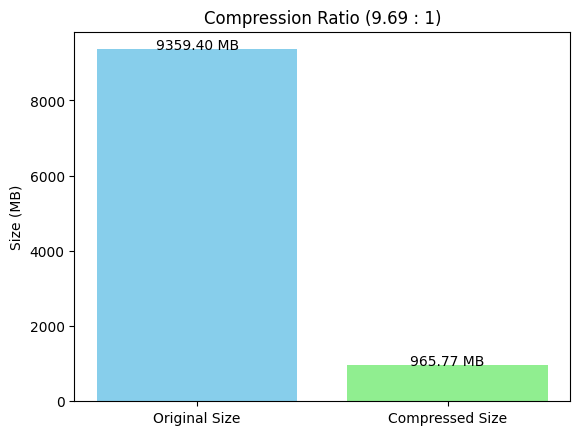

In [8]:
print(f"\nOriginal video tensor shape: {video_normalized.shape}")
print(f"Reconstructed video tensor shape: {reconstructed_video.shape}")

# Calculate and Plot Compression Ratio
original_size_bytes = video_normalized.nelement() * video_normalized.element_size()

compressed_size_bytes = 0
for file_name in os.listdir(output_folder):
    compressed_size_bytes += os.path.getsize(os.path.join(output_folder, file_name))
    
compression_ratio = original_size_bytes / compressed_size_bytes

print(f"Original size: {original_size_bytes / 1e6:.2f} MB")
print(f"Compressed size: {compressed_size_bytes / 1e6:.2f} MB")
print(f"Compression Ratio: {compression_ratio:.2f} : 1")

# Plotting
fig, ax = plt.subplots()
sizes = [original_size_bytes / 1e6, compressed_size_bytes / 1e6]
labels = ['Original Size', 'Compressed Size']
ax.bar(labels, sizes, color=['skyblue', 'lightgreen'])
ax.set_ylabel('Size (MB)')
ax.set_title(f'Compression Ratio ({compression_ratio:.2f} : 1)')

# Add text labels on top of bars
for i, size in enumerate(sizes):
    ax.text(i, size + 0.1, f'{size:.2f} MB', ha='center')
    
plt.show()

In [33]:
# Calculate PSNR in place
video_normalized -= reconstructed_video
video_normalized *= video_normalized
mse = torch.mean(video_normalized)
print(f"MSE: {mse.item():.6f}")

if mse == 0:
    psnr = float('inf')
else:
    max_pixel = 1.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
print(f"PSNR: {psnr:.2f} dB")

MSE: 0.000003
PSNR: 55.89 dB


/var/folders/tz/dk16058s17q23bj28chlys680000gn/T/ipykernel_81811/3658574631.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  psnr = 20 * np.log10(max_pixel / np.sqrt(mse))


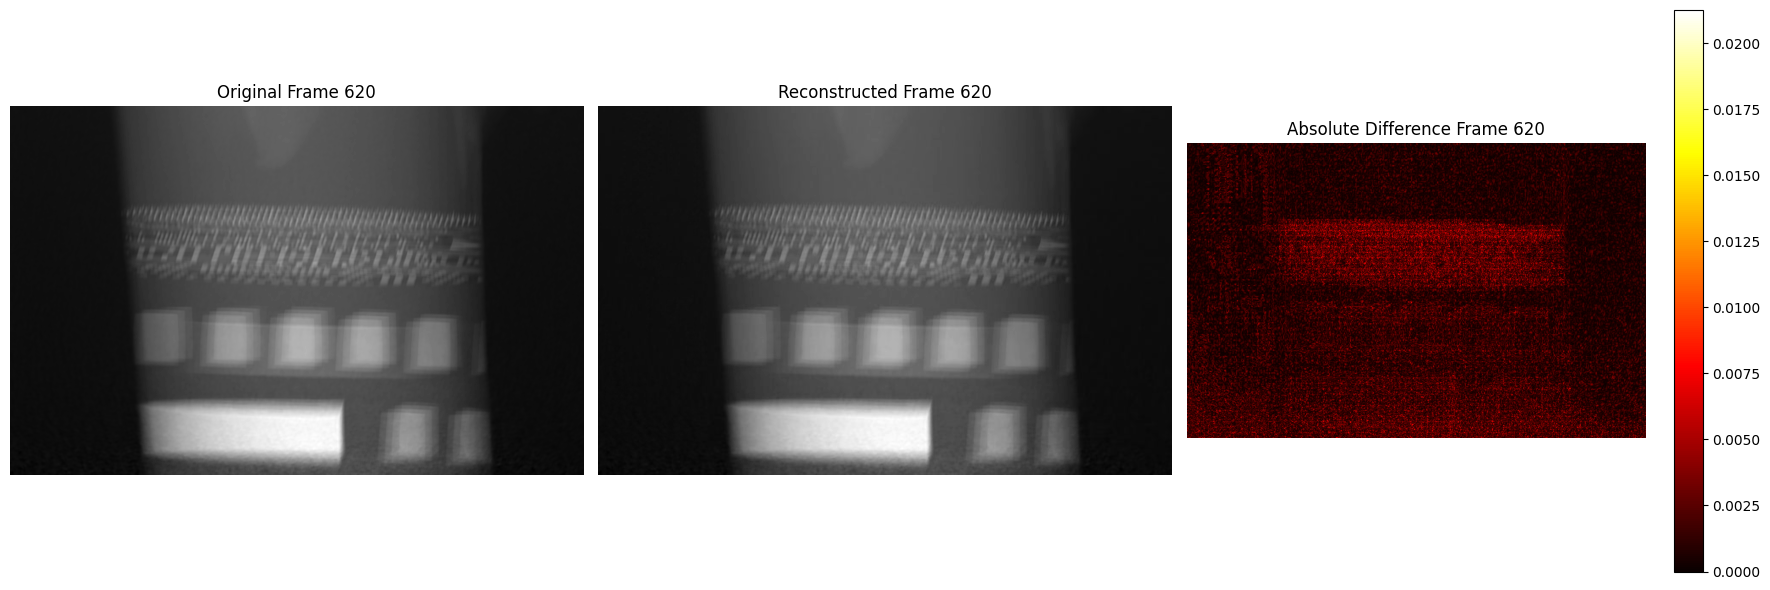

Frame 620 comparison:
Original range: [0.3470, 0.9364]
Reconstructed range: [0.3474, 0.9363]
Max absolute difference: 0.0213
Mean absolute difference: 0.0014


In [44]:
# Compare original and reconstructed frames side by side with difference
frame_idx = 620  # You can change this to compare different frames

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original frame
axes[0].imshow(video_normalized[frame_idx], cmap='gray')
axes[0].set_title(f'Original Frame {frame_idx}')
axes[0].axis('off')

# Reconstructed frame
axes[1].imshow(reconstructed_video[frame_idx], cmap='gray')
axes[1].set_title(f'Reconstructed Frame {frame_idx}')
axes[1].axis('off')

# Difference (absolute)
diff = torch.abs(video_normalized[frame_idx] - reconstructed_video[frame_idx])
im = axes[2].imshow(diff, cmap='hot')
axes[2].set_title(f'Absolute Difference Frame {frame_idx}')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Frame {frame_idx} comparison:")
print(f"Original range: [{video_normalized[frame_idx].min():.4f}, {video_normalized[frame_idx].max():.4f}]")
print(f"Reconstructed range: [{reconstructed_video[frame_idx].min():.4f}, {reconstructed_video[frame_idx].max():.4f}]")
print(f"Max absolute difference: {diff.max():.4f}")
print(f"Mean absolute difference: {diff.mean():.4f}")

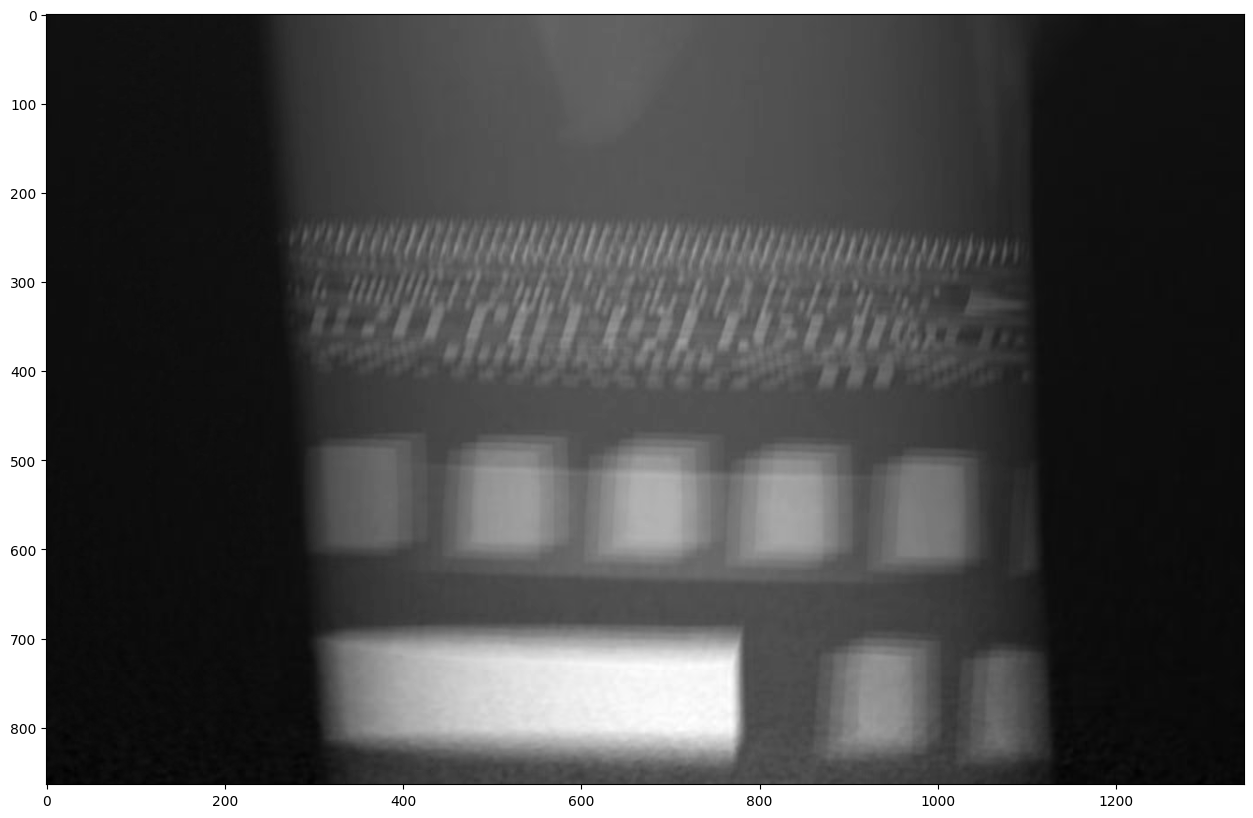

In [47]:
plt.figure(figsize=(20, 10))
plt.imshow(reconstructed_video[frame_idx], cmap='gray')

Analyzing slice 300
Original sinogram shape: (2015, 1344)
Reconstructed sinogram shape: (2015, 1344)
Angles shape: (2015, 1)
Angle range: [0.10, 180.10] degrees
Transposed sinogram shapes for iradon: (1344, 2015)
Performing FBP reconstruction on original sinogram...
Performing FBP reconstruction on compressed sinogram...
Performing FBP reconstruction on compressed sinogram...
FBP reconstruction shapes: (1344, 1344), (1344, 1344)

FBP Reconstruction PSNR for slice 300: 51.08 dB
FBP reconstruction shapes: (1344, 1344), (1344, 1344)

FBP Reconstruction PSNR for slice 300: 51.08 dB


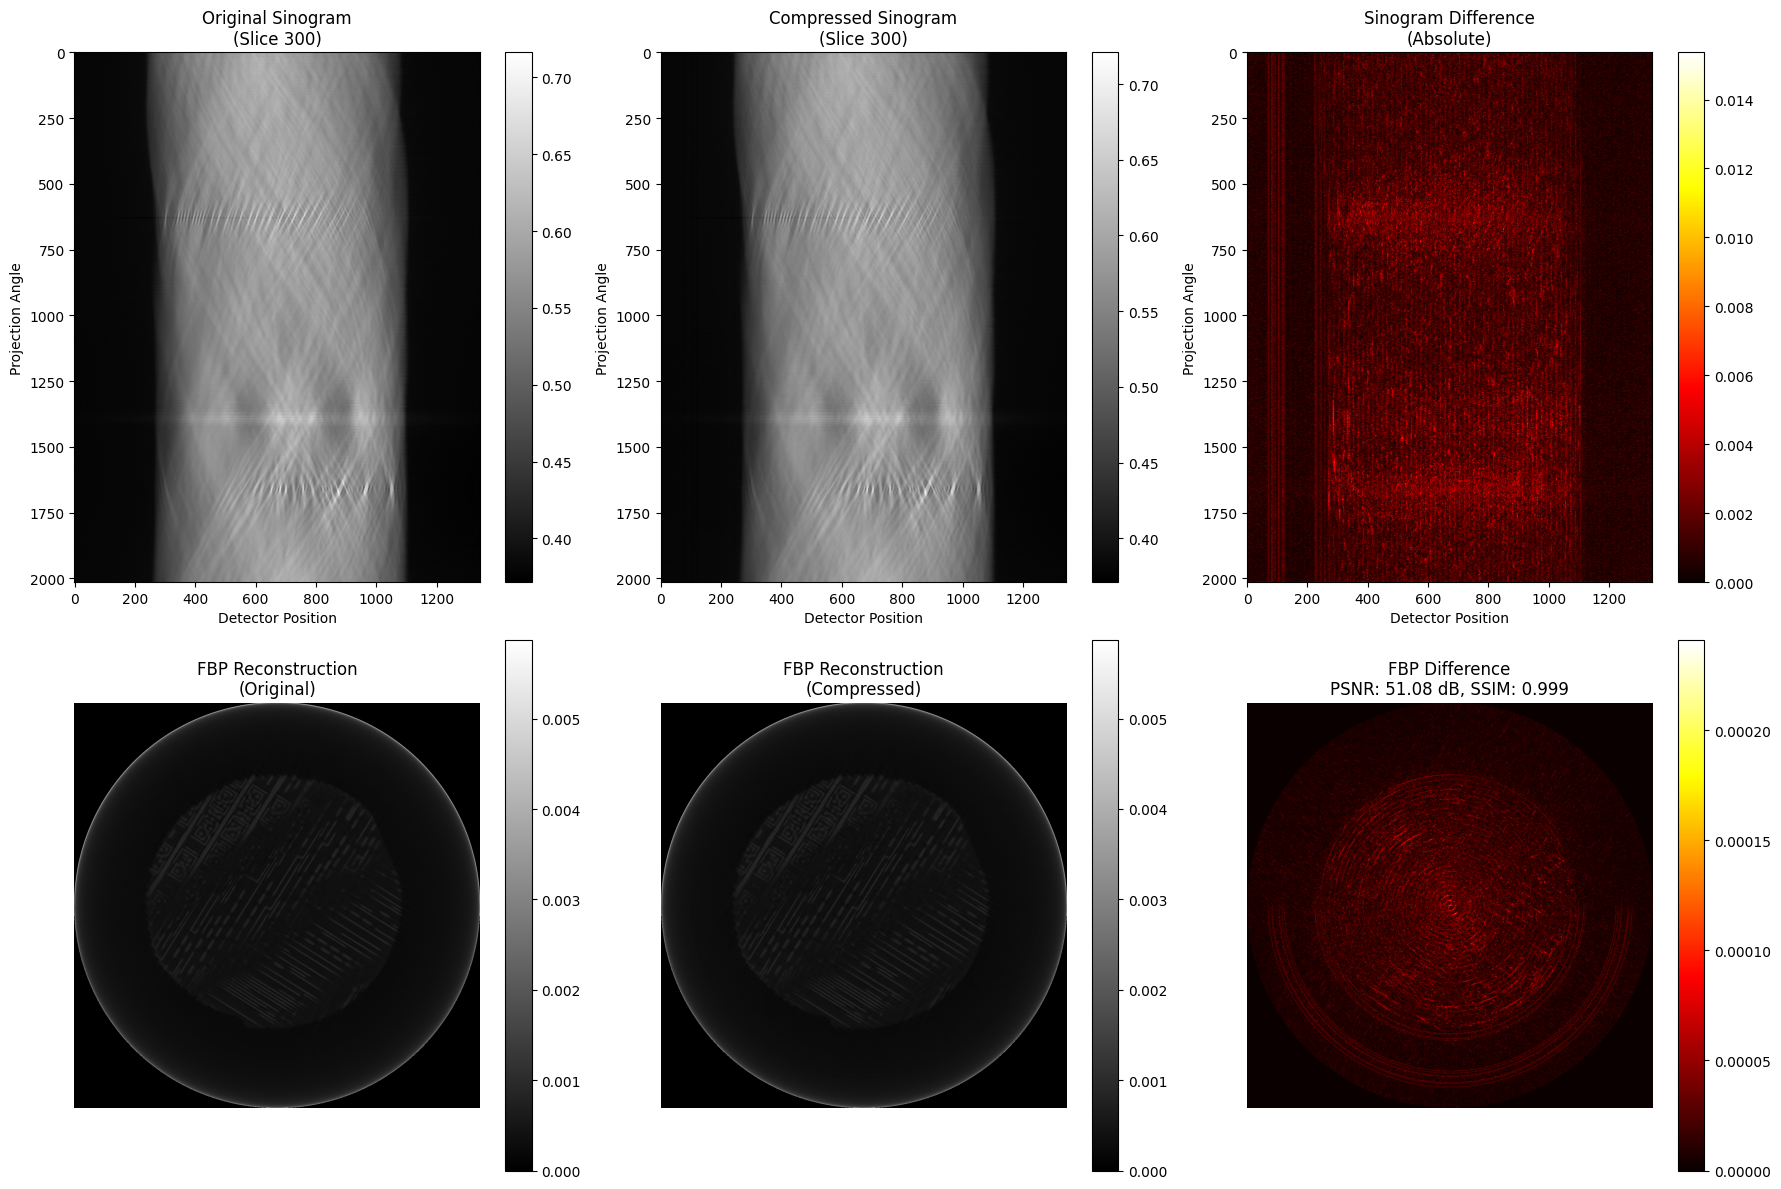


Detailed Quality Metrics for Slice 300:
  PSNR: 51.08 dB
  MSE: 0.000000
  MAE: 0.000010
  SSIM: 0.999041
  Cross-Correlation: 0.998923
  Max FBP difference: 0.000241
  Mean sinogram difference: 0.001293


In [51]:
## FBP Reconstruction Comparison for Single Slice

### Comparing the impact of compression on FBP reconstruction for a single slice from the sinogram data.

from skimage.transform import iradon

def compute_slice_fbp_reconstruction(slice_idx, video_normalized, reconstructed_video, angles, visualize=True):
    """
    Compute FBP reconstruction for a single slice and return quality metrics.
    
    Args:
        slice_idx (int): Index of the slice to reconstruct
        video_normalized (torch.Tensor): Original normalized video tensor
        reconstructed_video (torch.Tensor): Reconstructed video tensor after compression
        angles (np.ndarray): Projection angles
        visualize (bool): Whether to show visualization plots
    
    Returns:
        dict: Dictionary containing reconstruction results and quality metrics
    """
    
    # Extract sinograms for the selected slice
    original_sinogram = video_normalized[:, slice_idx, :].numpy()  # Shape: (n_angles, n_detectors)
    reconstructed_sinogram = reconstructed_video[:, slice_idx, :].numpy()

    if visualize:
        print(f"Analyzing slice {slice_idx}")
        print(f"Original sinogram shape: {original_sinogram.shape}")
        print(f"Reconstructed sinogram shape: {reconstructed_sinogram.shape}")
        print(f"Angles shape: {angles.shape}")

    # Convert angles to degrees and flatten
    angles_deg = angles.flatten() * 180 / np.pi if angles.max() <= np.pi else angles.flatten()
    if visualize:
        print(f"Angle range: [{angles_deg.min():.2f}, {angles_deg.max():.2f}] degrees")

    # Perform FBP reconstruction using scikit-image
    # Note: iradon expects sinogram shape (n_detectors, n_angles)
    original_sino_transposed = original_sinogram.T
    reconstructed_sino_transposed = reconstructed_sinogram.T

    if visualize:
        print(f"Transposed sinogram shapes for iradon: {original_sino_transposed.shape}")

    # FBP reconstruction
    if visualize:
        print("Performing FBP reconstruction on original sinogram...")
    fbp_original = iradon(original_sino_transposed, theta=angles_deg, 
                         filter_name='ramp', interpolation='linear')

    if visualize:
        print("Performing FBP reconstruction on compressed sinogram...")
    fbp_reconstructed = iradon(reconstructed_sino_transposed, theta=angles_deg,
                              filter_name='ramp', interpolation='linear')

    if visualize:
        print(f"FBP reconstruction shapes: {fbp_original.shape}, {fbp_reconstructed.shape}")

    # Calculate PSNR between the two reconstructions
    mse_fbp = np.mean((fbp_original - fbp_reconstructed) ** 2)
    if mse_fbp > 0:
        max_val = np.max(fbp_original)
        psnr_fbp = 20 * np.log10(max_val / np.sqrt(mse_fbp))
    else:
        psnr_fbp = float('inf')

    if visualize:
        print(f"\nFBP Reconstruction PSNR for slice {slice_idx}: {psnr_fbp:.2f} dB")

    # Calculate additional quality metrics
    mae_fbp = np.mean(np.abs(fbp_original - fbp_reconstructed))
    ncc_fbp = np.corrcoef(fbp_original.flatten(), fbp_reconstructed.flatten())[0, 1]
    
    # Calculate SSIM (Structural Similarity Index)
    def calculate_ssim(img1, img2):
        """Calculate SSIM between two images"""
        mu1 = np.mean(img1)
        mu2 = np.mean(img2)
        sigma1 = np.var(img1)
        sigma2 = np.var(img2)
        sigma12 = np.mean((img1 - mu1) * (img2 - mu2))
        
        c1 = (0.01 * np.max(img1)) ** 2
        c2 = (0.03 * np.max(img1)) ** 2
        
        ssim = ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))
        return ssim
    
    ssim_fbp = calculate_ssim(fbp_original, fbp_reconstructed)
    
    fbp_diff = np.abs(fbp_original - fbp_reconstructed)
    sino_diff = np.abs(original_sinogram - reconstructed_sinogram)

    # Visualization
    if visualize:
        # Visualize the results
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Original sinogram
        im1 = axes[0, 0].imshow(original_sinogram, cmap='gray', aspect='auto')
        axes[0, 0].set_title(f'Original Sinogram\n(Slice {slice_idx})')
        axes[0, 0].set_xlabel('Detector Position')
        axes[0, 0].set_ylabel('Projection Angle')
        plt.colorbar(im1, ax=axes[0, 0])

        # Reconstructed sinogram
        im2 = axes[0, 1].imshow(reconstructed_sinogram, cmap='gray', aspect='auto')
        axes[0, 1].set_title(f'Compressed Sinogram\n(Slice {slice_idx})')
        axes[0, 1].set_xlabel('Detector Position')
        axes[0, 1].set_ylabel('Projection Angle')
        plt.colorbar(im2, ax=axes[0, 1])

        # Sinogram difference
        im3 = axes[0, 2].imshow(sino_diff, cmap='hot', aspect='auto')
        axes[0, 2].set_title('Sinogram Difference\n(Absolute)')
        axes[0, 2].set_xlabel('Detector Position')
        axes[0, 2].set_ylabel('Projection Angle')
        plt.colorbar(im3, ax=axes[0, 2])

        # Original FBP reconstruction
        im4 = axes[1, 0].imshow(fbp_original, cmap='gray')
        axes[1, 0].set_title('FBP Reconstruction\n(Original)')
        axes[1, 0].axis('off')
        plt.colorbar(im4, ax=axes[1, 0])

        # Compressed FBP reconstruction
        im5 = axes[1, 1].imshow(fbp_reconstructed, cmap='gray')
        axes[1, 1].set_title('FBP Reconstruction\n(Compressed)')
        axes[1, 1].axis('off')
        plt.colorbar(im5, ax=axes[1, 1])

        # FBP difference
        im6 = axes[1, 2].imshow(fbp_diff, cmap='hot')
        axes[1, 2].set_title(f'FBP Difference\nPSNR: {psnr_fbp:.2f} dB, SSIM: {ssim_fbp:.3f}')
        axes[1, 2].axis('off')
        plt.colorbar(im6, ax=axes[1, 2])

        plt.tight_layout()
        plt.show()

        print(f"\nDetailed Quality Metrics for Slice {slice_idx}:")
        print(f"  PSNR: {psnr_fbp:.2f} dB")
        print(f"  MSE: {mse_fbp:.6f}")
        print(f"  MAE: {mae_fbp:.6f}")
        print(f"  SSIM: {ssim_fbp:.6f}")
        print(f"  Cross-Correlation: {ncc_fbp:.6f}")
        print(f"  Max FBP difference: {np.max(fbp_diff):.6f}")
        print(f"  Mean sinogram difference: {np.mean(sino_diff):.6f}")

    # Return results as dictionary
    return {
        'slice_idx': slice_idx,
        'fbp_original': fbp_original,
        'fbp_reconstructed': fbp_reconstructed,
        'original_sinogram': original_sinogram,
        'reconstructed_sinogram': reconstructed_sinogram,
        'psnr_fbp': psnr_fbp,
        'mse_fbp': mse_fbp,
        'mae_fbp': mae_fbp,
        'ssim_fbp': ssim_fbp,
        'ncc_fbp': ncc_fbp,
        'sino_diff_mean': np.mean(sino_diff),
        'fbp_diff_max': np.max(fbp_diff)
    }

# Test the function with the previous example
slice_idx = 300
result = compute_slice_fbp_reconstruction(slice_idx, video_normalized, reconstructed_video, angles, visualize=True)

Computing FBP reconstruction for 201 slices (range: 200-400)
This may take several minutes...


Processing slices:   0%|          | 0/201 [00:00<?, ?it/s]


Volume shapes:
  Original volume: (201, 1344, 1344)
  Reconstructed volume: (201, 1344, 1344)

🎯 Volume Quality Metrics:
Volume PSNR (VPSNR): 51.08 dB
Volume SSIM: 0.999036
Volume MSE: 0.000000
Volume MAE: 0.000010
Volume Cross-Correlation: 0.998924

📊 Slice-level Statistics:
  Mean slice PSNR: 51.70 ± 2.81 dB
  Min slice PSNR: 47.39 dB (slice 255)
  Max slice PSNR: 59.98 dB (slice 213)
  Mean slice SSIM: 0.9991 ± 0.0004
  Min slice SSIM: 0.9978 (slice 255)
  Max slice SSIM: 0.9999 (slice 213)

🎯 Volume Quality Metrics:
Volume PSNR (VPSNR): 51.08 dB
Volume SSIM: 0.999036
Volume MSE: 0.000000
Volume MAE: 0.000010
Volume Cross-Correlation: 0.998924

📊 Slice-level Statistics:
  Mean slice PSNR: 51.70 ± 2.81 dB
  Min slice PSNR: 47.39 dB (slice 255)
  Max slice PSNR: 59.98 dB (slice 213)
  Mean slice SSIM: 0.9991 ± 0.0004
  Min slice SSIM: 0.9978 (slice 255)
  Max slice SSIM: 0.9999 (slice 213)


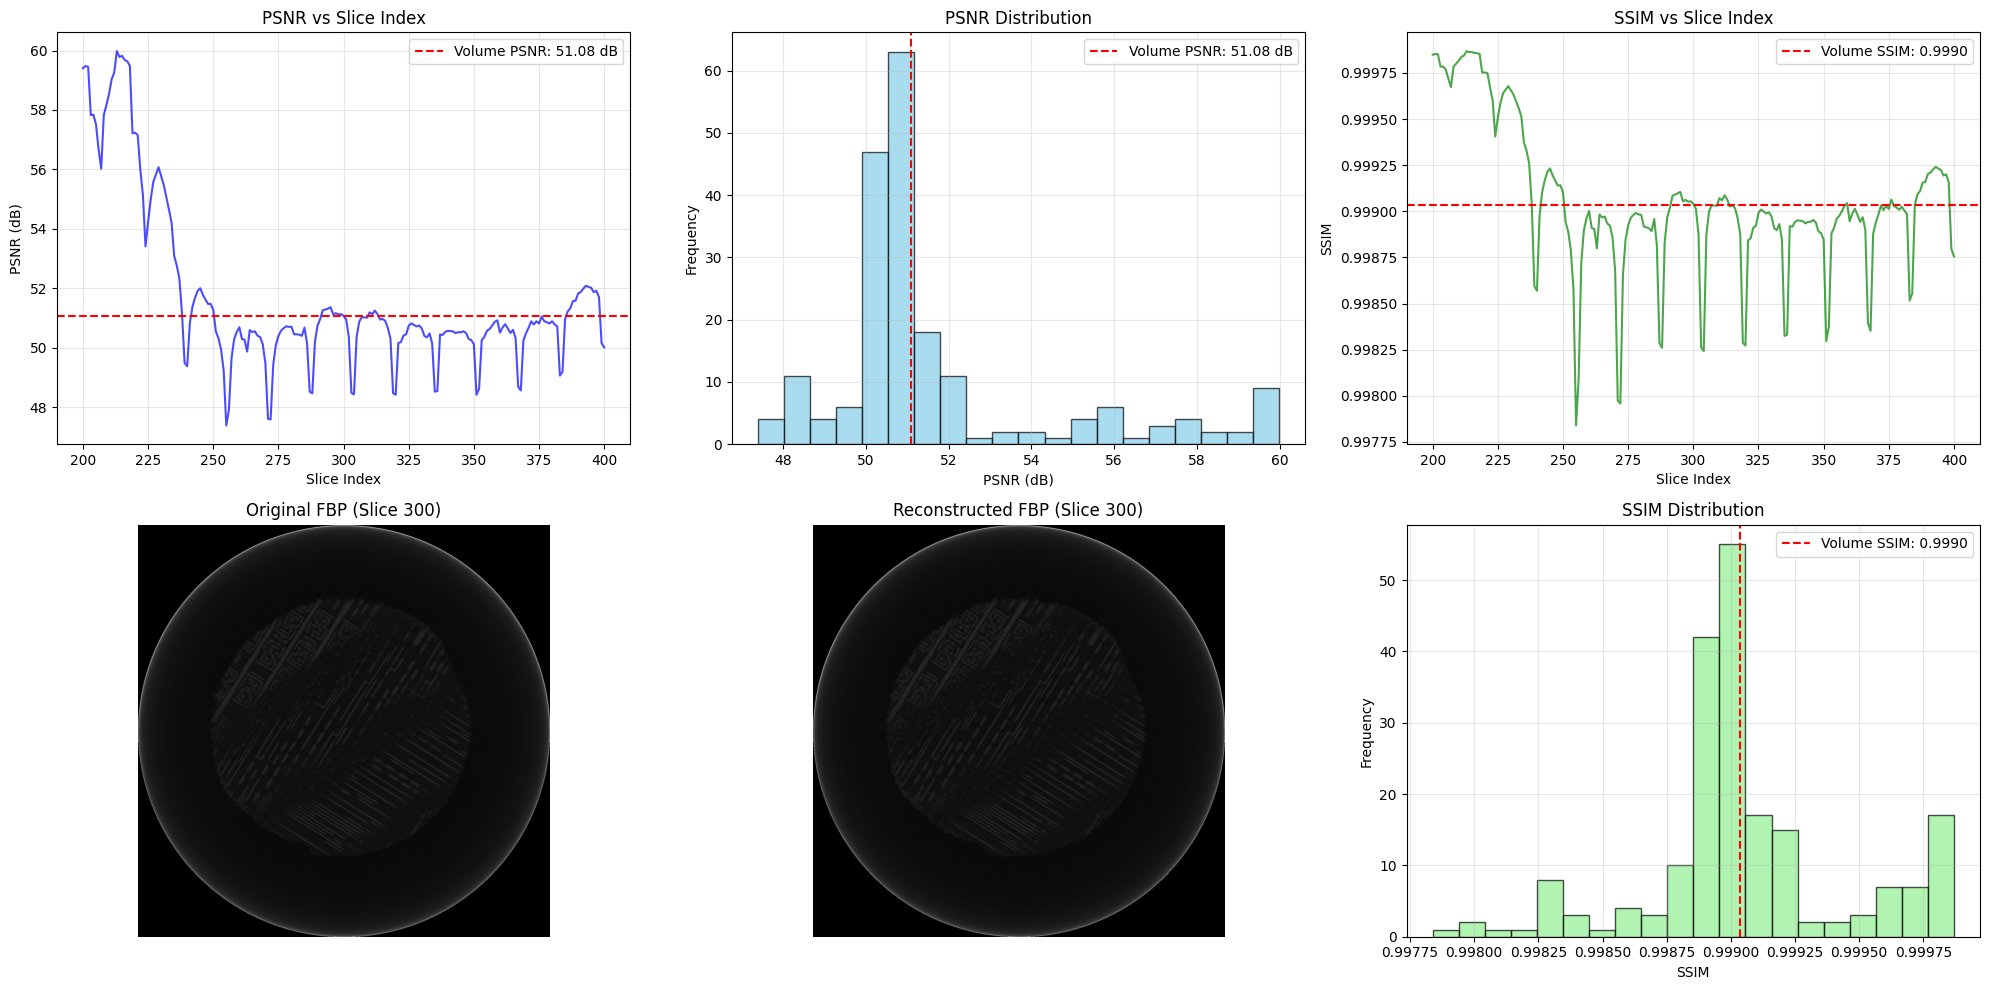

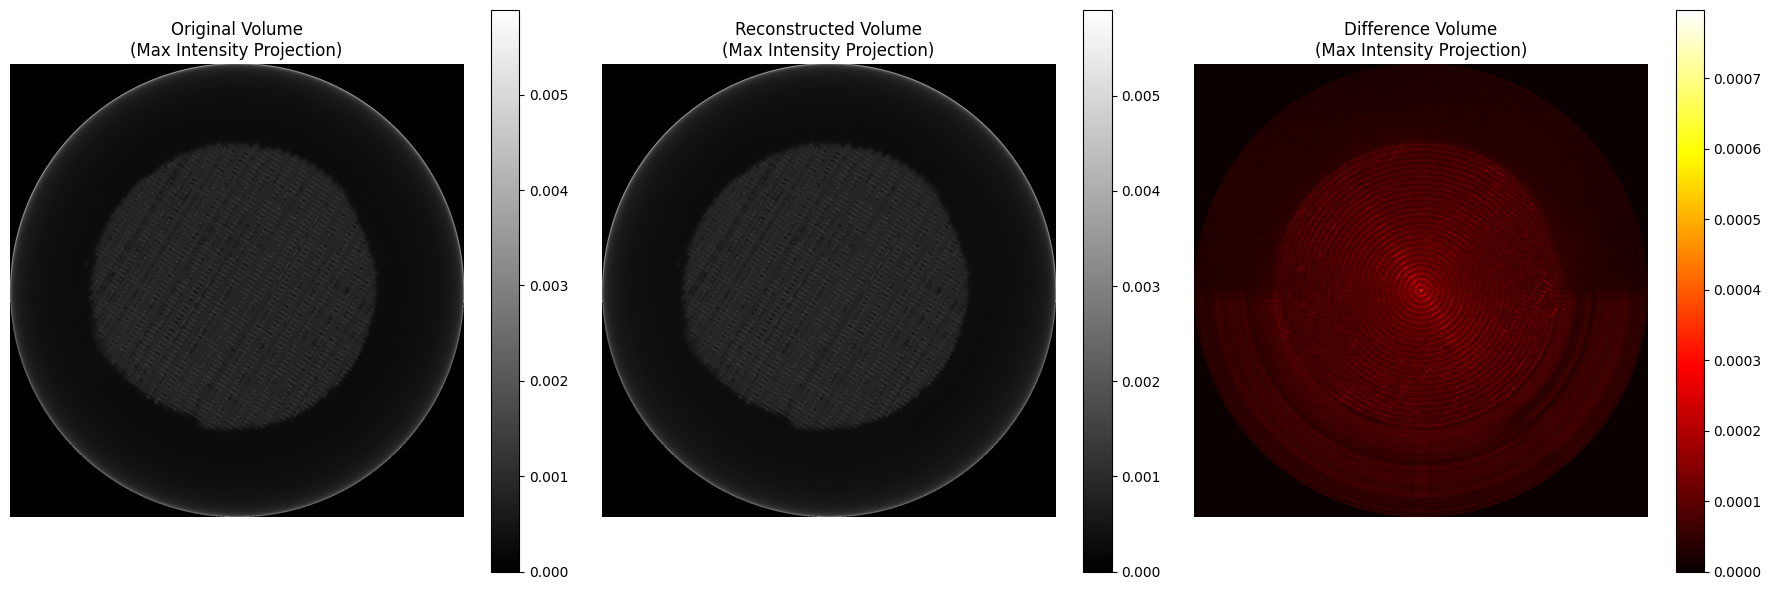


✅ Volume reconstruction complete!
   Range: slices 200-400 (201 slices)
   Volume PSNR: 51.08 dB
   Volume SSIM: 0.9990
   Volume shape: (201, 1344, 1344)
   Memory usage: ~1452.3 MB per volume


In [52]:
## Volume FBP Reconstruction and VPSNR Analysis

# Define slice range - can be modified as needed
slice_start = 200
slice_end = 400
slice_range = range(slice_start, slice_end + 1)
n_slices = len(slice_range)

print(f"Computing FBP reconstruction for {n_slices} slices (range: {slice_start}-{slice_end})")
print("This may take several minutes...")

# Initialize arrays to store the reconstructed volumes
volume_original = []
volume_reconstructed = []
slice_metrics = []

# Process each slice
from tqdm.auto import tqdm

for i, slice_idx in enumerate(tqdm(slice_range, desc="Processing slices")):
    # Compute FBP reconstruction for this slice (without visualization)
    result = compute_slice_fbp_reconstruction(
        slice_idx, video_normalized, reconstructed_video, angles, visualize=False
    )
    
    # Store the reconstructed slices
    volume_original.append(result['fbp_original'])
    volume_reconstructed.append(result['fbp_reconstructed'])
    
    # Store slice-level metrics
    slice_metrics.append({
        'slice_idx': slice_idx,
        'psnr': result['psnr_fbp'],
        'mse': result['mse_fbp'],
        'mae': result['mae_fbp'],
        'ssim': result['ssim_fbp'],
        'ncc': result['ncc_fbp']
    })

# Convert to numpy arrays for volume operations
volume_original = np.stack(volume_original, axis=0)  # Shape: (n_slices, height, width)
volume_reconstructed = np.stack(volume_reconstructed, axis=0)

print(f"\nVolume shapes:")
print(f"  Original volume: {volume_original.shape}")
print(f"  Reconstructed volume: {volume_reconstructed.shape}")

# Calculate Volume PSNR (VPSNR)
volume_mse = np.mean((volume_original - volume_reconstructed) ** 2)
if volume_mse > 0:
    max_val = np.max(volume_original)
    vpsnr = 20 * np.log10(max_val / np.sqrt(volume_mse))
else:
    vpsnr = float('inf')

# Calculate additional volume metrics
volume_mae = np.mean(np.abs(volume_original - volume_reconstructed))
volume_ncc = np.corrcoef(volume_original.flatten(), volume_reconstructed.flatten())[0, 1]

# Calculate Volume SSIM
def calculate_volume_ssim(vol1, vol2):
    """Calculate SSIM for entire volume"""
    mu1 = np.mean(vol1)
    mu2 = np.mean(vol2)
    sigma1 = np.var(vol1)
    sigma2 = np.var(vol2)
    sigma12 = np.mean((vol1 - mu1) * (vol2 - mu2))
    
    c1 = (0.01 * np.max(vol1)) ** 2
    c2 = (0.03 * np.max(vol1)) ** 2
    
    ssim = ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))
    return ssim

volume_ssim = calculate_volume_ssim(volume_original, volume_reconstructed)

print(f"\n🎯 Volume Quality Metrics:")
print(f"=" * 50)
print(f"Volume PSNR (VPSNR): {vpsnr:.2f} dB")
print(f"Volume SSIM: {volume_ssim:.6f}")
print(f"Volume MSE: {volume_mse:.6f}")
print(f"Volume MAE: {volume_mae:.6f}")
print(f"Volume Cross-Correlation: {volume_ncc:.6f}")

# Calculate slice-level statistics
slice_psnrs = [m['psnr'] for m in slice_metrics]
slice_mses = [m['mse'] for m in slice_metrics]
slice_maes = [m['mae'] for m in slice_metrics]
slice_ssims = [m['ssim'] for m in slice_metrics]

print(f"\n📊 Slice-level Statistics:")
print(f"  Mean slice PSNR: {np.mean(slice_psnrs):.2f} ± {np.std(slice_psnrs):.2f} dB")
print(f"  Min slice PSNR: {np.min(slice_psnrs):.2f} dB (slice {slice_range[np.argmin(slice_psnrs)]})")
print(f"  Max slice PSNR: {np.max(slice_psnrs):.2f} dB (slice {slice_range[np.argmax(slice_psnrs)]})")
print(f"  Mean slice SSIM: {np.mean(slice_ssims):.4f} ± {np.std(slice_ssims):.4f}")
print(f"  Min slice SSIM: {np.min(slice_ssims):.4f} (slice {slice_range[np.argmin(slice_ssims)]})")
print(f"  Max slice SSIM: {np.max(slice_ssims):.4f} (slice {slice_range[np.argmax(slice_ssims)]})")

# Visualize slice-level PSNR and SSIM distribution
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# PSNR vs slice index
axes[0, 0].plot(slice_range, slice_psnrs, 'b-', alpha=0.7)
axes[0, 0].set_xlabel('Slice Index')
axes[0, 0].set_ylabel('PSNR (dB)')
axes[0, 0].set_title('PSNR vs Slice Index')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=vpsnr, color='r', linestyle='--', label=f'Volume PSNR: {vpsnr:.2f} dB')
axes[0, 0].legend()

# PSNR histogram
axes[0, 1].hist(slice_psnrs, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 1].set_xlabel('PSNR (dB)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('PSNR Distribution')
axes[0, 1].axvline(x=vpsnr, color='r', linestyle='--', label=f'Volume PSNR: {vpsnr:.2f} dB')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# SSIM vs slice index
axes[0, 2].plot(slice_range, slice_ssims, 'g-', alpha=0.7)
axes[0, 2].set_xlabel('Slice Index')
axes[0, 2].set_ylabel('SSIM')
axes[0, 2].set_title('SSIM vs Slice Index')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].axhline(y=volume_ssim, color='r', linestyle='--', label=f'Volume SSIM: {volume_ssim:.4f}')
axes[0, 2].legend()

# Show sample slices from the volume
sample_slice_indices = [0, n_slices//4, n_slices//2, 3*n_slices//4, n_slices-1]
diff_volume = np.abs(volume_original - volume_reconstructed)

# Original vs reconstructed comparison for middle slice
mid_slice = n_slices // 2
axes[1, 0].imshow(volume_original[mid_slice], cmap='gray')
axes[1, 0].set_title(f'Original FBP (Slice {slice_range[mid_slice]})')
axes[1, 0].axis('off')

axes[1, 1].imshow(volume_reconstructed[mid_slice], cmap='gray')
axes[1, 1].set_title(f'Reconstructed FBP (Slice {slice_range[mid_slice]})')
axes[1, 1].axis('off')

# SSIM histogram
axes[1, 2].hist(slice_ssims, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 2].set_xlabel('SSIM')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('SSIM Distribution')
axes[1, 2].axvline(x=volume_ssim, color='r', linestyle='--', label=f'Volume SSIM: {volume_ssim:.4f}')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show volume difference visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Maximum intensity projection (MIP) views
mip_original = np.max(volume_original, axis=0)
mip_reconstructed = np.max(volume_reconstructed, axis=0)
mip_diff = np.max(diff_volume, axis=0)

im1 = axes[0].imshow(mip_original, cmap='gray')
axes[0].set_title('Original Volume\n(Max Intensity Projection)')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(mip_reconstructed, cmap='gray')
axes[1].set_title('Reconstructed Volume\n(Max Intensity Projection)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(mip_diff, cmap='hot')
axes[2].set_title(f'Difference Volume\n(Max Intensity Projection)')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"\n✅ Volume reconstruction complete!")
print(f"   Range: slices {slice_start}-{slice_end} ({n_slices} slices)")
print(f"   Volume PSNR: {vpsnr:.2f} dB")
print(f"   Volume SSIM: {volume_ssim:.4f}")
print(f"   Volume shape: {volume_original.shape}")
print(f"   Memory usage: ~{volume_original.nbytes / 1e6:.1f} MB per volume")